# Compare the oscillatory activity/clusterisation

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
from pesco.experimental.clustering import (
    cluster_bands,
    cluster_peak_frequencies,
    find_k_with_no_peak,
    get_no_peak,
    order_clusters_by_peak,
)
from pesco.experimental.peak_testing import (
    compute_intervals,
    cutintervals,
    test_lobes,
    test_regions,
    test_regions_heatmap,
)
from pesco.experimental.plotting import (
    plot_cluster_brain,
    plot_clusters,
    plot_clusters_pair,
    plot_histogram,
    plot_lobes,
    plot_region_difference_heatmap,
    plot_region_difference_heatmap_pair,
    plot_regions,
)
from pesco.io import load_sources, prepare_psd
from pesco.pipeline import DatasetCtx
from pesco.preprocess import compute_psd, normalize_psd

seed = 3
np.random.seed(seed)

PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")

In [16]:
import joblib
from pathlib import Path
CACHE = Path(PROJECT_DIR , "data/interim/clustering/cache")
IMAGES_PATH =  Path(PROJECT_DIR , "analiza/images")
print(IMAGES_PATH )
ieeg = joblib.load(CACHE / "intracranial_data.joblib")
src  = joblib.load(CACHE / "reconstructed_sources.joblib")


/Users/daniel/PhD/spectral-comparison/code/analiza/images


## Similarity: iEEG vs reconstructed sources

Compares `channel_fraction` per (region, frequency-bin) cell from `regional_diff`.
Improvements over a naive global Spearman:

- Restrict cell-wise correlation to the **union mask** (cells significant in at least one modality) to avoid joint-zero inflation.
- Report a separate **Jaccard** of significance masks for pattern overlap independent of magnitude.
- Drop subcortical regions (hippocampus, amygdala) before scalar comparison: source reconstruction has no surface coverage.
- Per-canonical-band breakout (delta/theta/alpha/beta/gamma) following Afnan et al. 2023.
- Approximate spatial null via region-label shuffling of one map (independence-violating p-values from `spearmanr` are *not* trusted).
- Frame as agreement-of-pattern, not validation-of-amplitude. Density of source map ≥ iEEG by construction (more vertices/region).

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

SUBCORTICAL = {"Hippocampus", "Amygdala"}  # excluded from cross-modal scalars

def to_matrix(df, value_col="channel_fraction"):
    d = df[~df["is_lobe_row"]] if "is_lobe_row" in df.columns else df
    return d.pivot_table(index="Region name", columns="interval",
                         values=value_col, aggfunc="first")

A_full = to_matrix(ieeg.regional_diff)
B_full = to_matrix(src.regional_diff)

regions = [r for r in A_full.index.intersection(B_full.index) if r not in SUBCORTICAL]
intervals = A_full.columns.intersection(B_full.columns)
A = A_full.loc[regions, intervals]
B = B_full.loc[regions, intervals]

print(f"shared regions: {len(regions)}  shared intervals: {len(intervals)}")
print(f"dropped subcortical: {sorted(set(A_full.index) & SUBCORTICAL)}")

shared regions: 21  shared intervals: 8
dropped subcortical: []


### Cell-wise summary (union mask)

Spearman across all (region × interval) cells significant in **at least one** modality. Avoids the inflation from
the bulk of jointly non-significant cells. Jaccard reports raw pattern overlap.

In [5]:
a = A.to_numpy().ravel()
b = B.to_numpy().ravel()
sa, sb = ~np.isnan(a), ~np.isnan(b)

union = sa | sb
both = sa & sb

a_u = np.nan_to_num(a[union], nan=0.0)
b_u = np.nan_to_num(b[union], nan=0.0)
rho_union, _ = spearmanr(a_u, b_u) if union.sum() >= 3 else (np.nan, np.nan)

rho_both, _ = spearmanr(a[both], b[both]) if both.sum() >= 3 else (np.nan, np.nan)

jaccard = both.sum() / max(union.sum(), 1)
abs_diff_union = float(np.mean(np.abs(a_u - b_u)))

print(f"union-mask  n={int(union.sum()):4d}  rho={rho_union:+.3f}  mean|diff|={abs_diff_union:.3f}")
print(f"both-sig    n={int(both.sum()):4d}  rho={rho_both:+.3f}")
print(f"sig pattern jaccard={jaccard:.3f}  iEEG-only={int((sa & ~sb).sum())}  src-only={int((~sa & sb).sum())}  both={int(both.sum())}")

union-mask  n=  76  rho=-0.399  mean|diff|=0.350
both-sig    n=  13  rho=+0.039
sig pattern jaccard=0.171  iEEG-only=24  src-only=39  both=13


### Per-canonical-band breakout

Aggregate fine bins to canonical bands by interval midpoint. Reports Spearman across all regions per band
(union mask within band).

In [6]:
BANDS = [
    ("delta",  0.0,  4.0),
    ("theta",  4.0,  8.0),
    ("alpha",  8.0, 13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 80.0),
]

def interval_mid(label):
    # labels look like '(0.75, 1.25]'
    lo, hi = label.strip("(]").split(",")
    return 0.5 * (float(lo) + float(hi))

interval_to_band = {
    iv: next((name for name, lo, hi in BANDS if lo <= interval_mid(iv) < hi), None)
    for iv in intervals
}

rows = []
for name, _, _ in BANDS:
    cols = [iv for iv in intervals if interval_to_band[iv] == name]
    if not cols:
        continue
    a_b = A[cols].to_numpy().ravel()
    b_b = B[cols].to_numpy().ravel()
    sa_b, sb_b = ~np.isnan(a_b), ~np.isnan(b_b)
    u = sa_b | sb_b
    if u.sum() < 3:
        rho = np.nan
    else:
        rho, _ = spearmanr(np.nan_to_num(a_b[u]), np.nan_to_num(b_b[u]))
    jac = (sa_b & sb_b).sum() / max(u.sum(), 1)
    rows.append({"band": name, "n_bins": len(cols),
                 "n_union": int(u.sum()), "spearman": rho, "jaccard": jac})

band_summary = pd.DataFrame(rows)
band_summary

,band,n_bins,n_union,spearman,jaccard
0,theta,2,12,-0.813151,0.000000
1,alpha,3,42,-0.220196,0.261905
2,beta,3,22,-0.531672,0.090909


### Spatial null via region-label shuffle

Shuffle region labels of `B` and recompute the union-mask Spearman. Repeat 1000×. The resulting null
distribution accounts for the (region × interval) dependence structure better than the parametric `spearmanr`
p-value, though it is weaker than a proper spin test (Alexander-Bloch et al. 2018) which preserves spatial
autocorrelation. Treat as a sanity check, not a definitive test.

In [7]:
rng = np.random.default_rng(0)
n_perm = 1000
null = np.empty(n_perm)
B_arr = B.to_numpy()
A_flat = np.nan_to_num(A.to_numpy()).ravel()
A_mask = ~np.isnan(A.to_numpy()).ravel()
for k in range(n_perm):
    perm = rng.permutation(B_arr.shape[0])
    Bk = B_arr[perm].ravel()
    sb_k = ~np.isnan(Bk)
    u = A_mask | sb_k
    rho, _ = spearmanr(A_flat[u], np.nan_to_num(Bk)[u])
    null[k] = rho
p_perm = (np.sum(null >= rho_union) + 1) / (n_perm + 1)
print(f"observed rho={rho_union:+.3f}  null mean={null.mean():+.3f}  null sd={null.std():.3f}  p_perm={p_perm:.3f}")

observed rho=-0.399  null mean=-0.520  null sd=0.093  p_perm=0.108


### Per-region scalar (for atlas plot)

Two metrics per ROI: (1) Spearman across freq bins on the union mask within that region; (2) mean absolute
difference of `channel_fraction` (NaN→0). Hippocampus and amygdala kept here for completeness but will not
render on the cortical atlas.

In [8]:
import re

def slugify(s):
    s = s.lower()
    s = re.sub(r"[()]", "", s)
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    return s

def per_region_spearman(a, b):
    sa_r, sb_r = ~np.isnan(a), ~np.isnan(b)
    u = sa_r | sb_r
    if u.sum() < 3:
        return np.nan
    rho, _ = spearmanr(np.nan_to_num(a[u]), np.nan_to_num(b[u]))
    return rho

# cortical only (paragraph: subcortical dropped before all three statistics)
scores = pd.DataFrame({
    "region": regions,
    "spearman": [per_region_spearman(A.loc[r].values, B.loc[r].values) for r in regions],
    "abs_diff": (A.fillna(0) - B.fillna(0)).abs().mean(axis=1).values,
    "n_union":  [int(((~np.isnan(A.loc[r].values)) | (~np.isnan(B.loc[r].values))).sum())
                 for r in regions],
})
scores["slug"] = scores["region"].map(slugify)

# report subcortical separately (cannot project to source space)
subcortical_present = sorted(set(A_full.index) & SUBCORTICAL & set(B_full.index))
if subcortical_present:
    sub_rows = []
    for r in subcortical_present:
        a, b = A_full.loc[r].values, B_full.loc[r].values
        sub_rows.append({
            "region": r,
            "spearman": per_region_spearman(a, b),
            "abs_diff": float(np.abs(np.nan_to_num(a) - np.nan_to_num(b)).mean()),
            "n_union":  int(((~np.isnan(a)) | (~np.isnan(b))).sum()),
        })
    print("subcortical (reported separately, not on atlas):")
    print(pd.DataFrame(sub_rows).to_string(index=False))

scores.sort_values("spearman", ascending=False)

<positron-console-cell-8>:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


,region,spearman,abs_diff,n_union,slug
16,'Superior and middle occipital gyri',0.410391,0.150846,5,superior_and_middle_occipital_gyri
8,'Lingual gyrus and occipital fusiform gyrus',0.000000,0.098571,3,lingual_gyrus_and_occipital_fusiform_gyrus
15,'Precentral gyrus',-0.114708,0.189078,5,precentral_gyrus
18,'Superior parietal lobule',-0.223906,0.221264,6,superior_parietal_lobule
3,'Cuneus',-0.373176,0.273026,6,cuneus
4,'Fusiform and parahippocampal gyri',-0.447214,0.232602,5,fusiform_and_parahippocampal_gyri
14,'Postcentral gyrus (including medial segment)',-0.462031,0.270970,6,postcentral_gyrus_including_medial_segment
17,'Superior frontal gyrus and frontal pole',-0.674200,0.278053,6,superior_frontal_gyrus_and_frontal_pole
7,'Inferior temporal gyrus',-0.866025,0.110960,3,inferior_temporal_gyrus
10,'Middle temporal gyrus',-0.866025,0.098945,3,middle_temporal_gyrus


### Atlas plot (Frauscher 38-region)

Cortical-surface visualization of per-ROI Spearman. Hippocampus + amygdala lack 2D geometry — `geom_brain`
warns and skips. Switch `metric` to `'abs_diff'` for divergence view.

in atlas, not in scores: {'orbital_part_of_inferior_frontal_gyrus', 'calcarine_cortex', 'medial_segment_of_precentral_gyrus', 'supramarginal_gyrus', 'amygdala', 'temporal_pole_and_planum_polare', 'central_operculum', 'inferior_occipital_gyrus_and_occipital_pole', 'gyrus_rectus_and_orbital_gyri', 'middle_cingulate', 'precuneus', 'posterior_insula', 'superior_temporal_gyrus', 'frontal_operculum', 'medial_frontal_cortex', 'posterior_cingulate', 'transverse_temporal_gyrus', 'medial_segment_of_superior_frontal_gyrus'}
in scores, not in atlas: {'inferior_ocipital_gyrus_and_occipital_pole'}


/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/ggsegpy/geom_brain.py:70: UserWarning: Data contains values not in atlas 'label' column: {'lh_r38', 'rh_r37', 'lh_r37', 'rh_r38'}
/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/daniel/PhD/spectral-comparison/code/analiza/images/per_roi_spearman_atlas.svg


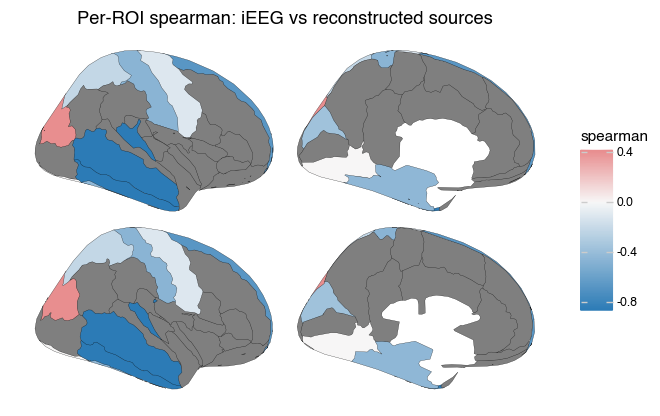

In [17]:
from pesco.atlases import load_frauscher
from ggsegpy.geom_brain import geom_brain
from plotnine import ggplot, aes, theme_void, scale_fill_gradient, scale_fill_gradient2, labs

frauscher_atlas = load_frauscher()
core = frauscher_atlas.core

missing_in_scores = set(core["region"].unique()) - set(scores["slug"])
missing_in_atlas  = set(scores["slug"]) - set(core["region"].unique())
print("in atlas, not in scores:", missing_in_scores)
print("in scores, not in atlas:", missing_in_atlas)

metric = "spearman"  # or "abs_diff"
vals = (core[["label", "region"]]
        .merge(scores[["slug", metric]], left_on="region", right_on="slug", how="left")
        .rename(columns={metric: "value"})
        [["label", "value"]])

if metric == "abs_diff":
    fill_scale = scale_fill_gradient(low="#f7f7f7", high="#d7191c")
else:
    fill_scale = scale_fill_gradient2(low="#2c7bb6", mid="#f7f7f7", high="#d7191c", midpoint=0)

p_atlas = (
    ggplot(vals, aes(fill="value"))
    + geom_brain(atlas=frauscher_atlas, mapping=aes(fill="value"))
    + fill_scale
    + theme_void()
    + labs(title=f"Per-ROI {metric}: iEEG vs reconstructed sources", fill=metric)
)
p_atlas.save(f"{IMAGES_PATH}/per_roi_{metric}_atlas.svg", width=10, height=6, dpi=150)
p_atlas

/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/ggsegpy/geom_brain.py:70: UserWarning: Data contains values not in atlas 'label' column: {'lh_r38', 'rh_r37', 'lh_r37', 'rh_r38'}
/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/daniel/PhD/spectral-comparison/code/analiza/images/per_roi_abs_diff_atlas.svg


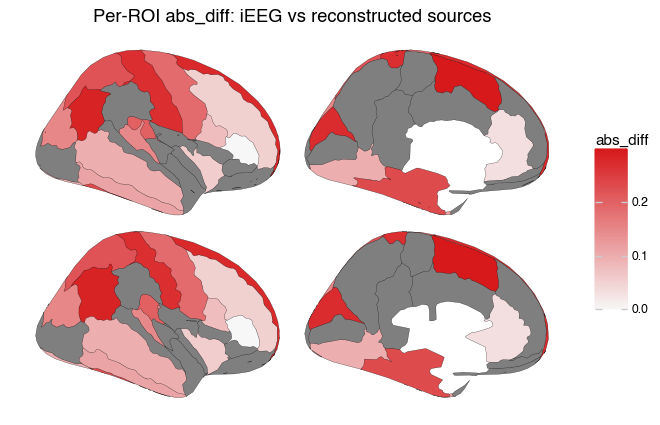

In [19]:
metric =  "abs_diff"
vals = (core[["label", "region"]]
        .merge(scores[["slug", metric]], left_on="region", right_on="slug", how="left")
        .rename(columns={metric: "value"})
        [["label", "value"]])

if metric == "abs_diff":
    fill_scale = scale_fill_gradient(low="#f7f7f7", high="#d7191c")
else:
    fill_scale = scale_fill_gradient2(low="#2c7bb6", mid="#f7f7f7", high="#d7191c", midpoint=0)

p_atlas = (
    ggplot(vals, aes(fill="value"))
    + geom_brain(atlas=frauscher_atlas, mapping=aes(fill="value"))
    + fill_scale
    + theme_void()
    + labs(title=f"Per-ROI {metric}: iEEG vs reconstructed sources", fill=metric)
)
p_atlas.save(f"{IMAGES_PATH}/per_roi_{metric}_atlas.svg", width=10, height=6, dpi=150)
p_atlas